In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
caminho = r"H:\Python\3°-Etapa\Atividade_5_CSV\Tabela4.csv"

In [21]:
dvm_humano = pd.read_csv(caminho, sep=";", header=1, encoding="latin1",decimal=",")

In [22]:
dvm_humano.head(5)

,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759


In [38]:
dvm_humano.sort_values(by="Sigla", ascending=True)

,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Diferença
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754,0.352
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746,0.376
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767,0.337
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759,0.287
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759,0.373
5,CE,23,Ceará,0.405,0.541,0.682,0.709,0.712,0.717,0.723,0.727,0.737,0.746,0.754,0.753,0.740,0.759,0.773,0.773,0.368
6,DF,53,Distrito Federal,0.616,0.725,0.824,0.824,0.834,0.834,0.833,0.842,0.842,0.845,0.860,0.837,0.823,0.867,0.870,0.866,0.250
7,ES,32,Espírito Santo,0.505,0.640,0.740,0.747,0.755,0.763,0.766,0.766,0.769,0.776,0.780,0.773,0.754,0.782,0.803,0.804,0.299
8,GO,52,Goiás,0.487,0.615,0.735,0.744,0.753,0.759,0.758,0.765,0.770,0.776,0.780,0.777,0.755,0.797,0.809,0.815,0.328
9,MA,21,Maranhão,0.357,0.476,0.639,0.669,0.682,0.683,0.690,0.698,0.704,0.706,0.715,0.715,0.701,0.730,0.740,0.745,0.388


In [33]:
anos = [c for c in dvm_humano.columns if str(c).isdigit()]
print(anos)

id_vars = [c for c in dvm_humano.columns if c not in anos]
dvm_humano_longo = dvm_humano.melt(
    id_vars=id_vars,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH",
)
dvm_humano_longo["Ano"] = dvm_humano_longo["Ano"].astype(int)
dvm_humano_longo["IDH"] = pd.to_numeric(dvm_humano_longo["IDH"], errors="coerce")
dvm_humano_longo.head(5)


['1991', '2000', '2010', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


,Sigla,Código,Estado,Ano,IDH
0,AC,12,Acre,1991,0.402
1,AL,27,Alagoas,1991,0.370
2,AM,13,Amazonas,1991,0.430
3,AP,16,Amapá,1991,0.472
4,BA,29,Bahia,1991,0.386


In [34]:
minas = dvm_humano_longo[dvm_humano_longo["Estado"]=="Minas Gerais"] 

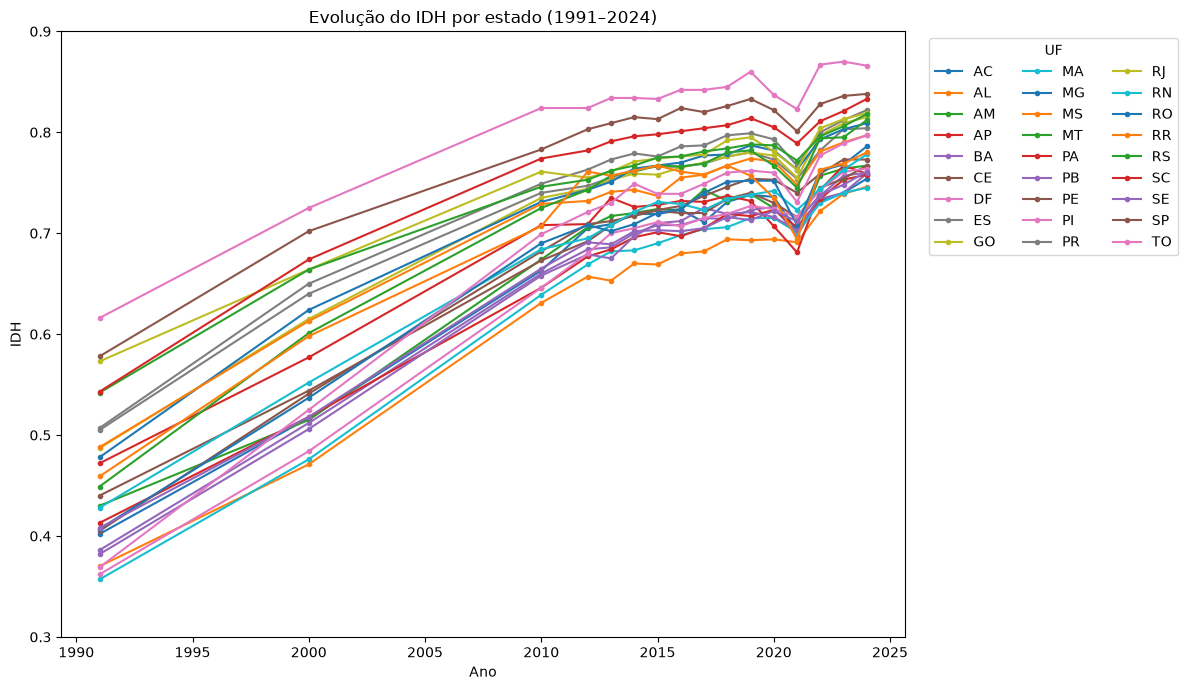

In [36]:
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in dvm_humano_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(grupo["Ano"], grupo["IDH"], marker="o", markersize=3, linewidth=1.5, label=sigla)

ax.set_title("Evolução do IDH por estado (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
plt.show()

In [37]:
dvm_humano["Diferença"] = dvm_humano["2024"] - dvm_humano["1991"]

In [39]:
dvm_humano.sort_values(by="Diferença", ascending=False)

,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Diferença
26,TO,17,Tocantins,0.369,0.525,0.699,0.721,0.730,0.749,0.739,0.739,0.749,0.760,0.762,0.760,0.731,0.777,0.789,0.797,0.428
16,PI,22,Piauí,0.362,0.484,0.646,0.680,0.700,0.705,0.711,0.707,0.715,0.719,0.727,0.724,0.716,0.743,0.761,0.764,0.402
9,MA,21,Maranhão,0.357,0.476,0.639,0.669,0.682,0.683,0.690,0.698,0.704,0.706,0.715,0.715,0.701,0.730,0.740,0.745,0.388
20,RO,11,Rondônia,0.407,0.537,0.690,0.708,0.702,0.709,0.720,0.724,0.740,0.751,0.752,0.752,0.708,0.762,0.768,0.786,0.379
14,PB,25,Paraíba,0.382,0.506,0.658,0.679,0.675,0.697,0.710,0.712,0.725,0.719,0.721,0.716,0.703,0.737,0.757,0.760,0.378
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746,0.376
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759,0.373
5,CE,23,Ceará,0.405,0.541,0.682,0.709,0.712,0.717,0.723,0.727,0.737,0.746,0.754,0.753,0.740,0.759,0.773,0.773,0.368
12,MT,51,Mato Grosso,0.449,0.601,0.725,0.743,0.757,0.761,0.767,0.766,0.769,0.780,0.782,0.767,0.745,0.794,0.795,0.812,0.363
24,SE,28,Sergipe,0.408,0.518,0.665,0.691,0.689,0.702,0.703,0.702,0.705,0.716,0.713,0.722,0.712,0.738,0.748,0.761,0.353
